# AutoRev
This project is to build a prototype app that shows the feasibility of systemic review automation for reviewing publications consistently for the inclusion and exclusion criteria of a specific primary paper aim. As an article reviewer for systemic reivews we reivew titles, abstracts, discussion conclusion to determine if the article meets the systemic reivew inclusion/exclusion critiera and then use results and methods and even conclsuions to identify key results to eventually summarize

- XML scraping and metadata already handled in corpus_scrape.py

## Config

In [1]:
import os
import requests
import xml.etree.ElementTree as ET
import time
import pandas as pd
import numpy as np
import nltk 
import string
import matplotlib.pyplot as plt
import seaborn as sns
import re
%matplotlib inline
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer # build tf-idf matrix

from pathlib import Path

# get top words and tokenized functions
import re, nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download("punkt")
nltk.download("stopwords")
stop = set(stopwords.words("english"))

# additional configuation
ROOT = Path.cwd().parent
DATA = ROOT / "data"
CODE = ROOT / "code"
DATA_VIS = ROOT / "data_vis"

print("ROOT:", ROOT)
print("DATA exists:", DATA.exists())
print("DATA_VIS exists:", DATA_VIS.exists())


## Data Processing

### Pull Data File

In [3]:
labels_path = DATA / "corpus_labels.csv"
df = pd.read_csv(labels_path, encoding="ISO-8859-1")
df.columns

Index(['pmcid', 'file_path', 'title_lenght', 'title', 'journal', 'pub_year',
       'word_count', 'sentence_count', 'label_q1', 'label_q2',
       'checking_website', 'legit_coloncancer_article', 'note', 'sg_query',
       'th_query'],
      dtype='object')

### Get Stop Words and Tokenized Funcitons

### Define extractor + tokenizer

In [7]:
import xml.etree.ElementTree as ET
import re
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

def extract_sections(path):
    """
    Parses a PMC XML file and extracts major sections of the article:
    - Tries to detect sections using <sec> tags and <title> text
    - If structured tags aren't present, falls back to heuristics (e.g., splitting on "Introduction", "Methods", etc.)
    - Returns a dictionary with raw (non-tokenized) text for each section.
    """

    try:
        # Parse XML
        tree = ET.parse(path)
        root = tree.getroot()
        ns = {"jats": "https://jats.nlm.nih.gov/ns/archiving/1.3/"}

        # Locate top-level sections
        body = root.find(".//jats:body", ns)
        abstract = root.find(".//jats:abstract", ns)
        title = root.find(".//jats:article-title", ns)

        # Pre-fill section slots (all lowercase keys)
        sections = {
            "title": title.text.strip() if title is not None and title.text else "",
            "abstract": ET.tostring(abstract, encoding="unicode", method="text").strip() if abstract is not None else "",
            "introduction": "",
            "methods": "",
            "results": "",
            "discussion": "",
            "conclusion": "",
            "other": ""  # For unmatched or fallback content
        }

        # --------------------------------------
        # Phase 1: Try structured XML tags
        # --------------------------------------
        found_structured = False
        if body is not None:
            for sec in body.findall(".//jats:sec", ns):
                # Try to identify section name by attribute or heading text
                sec_type = sec.attrib.get("sec-type", "").lower()
                title_el = sec.find("jats:title", ns)
                title_text = title_el.text.lower() if title_el is not None and title_el.text else ""

                # Pull plain text of this section
                content = ET.tostring(sec, encoding="unicode", method="text").strip()

                # Match to known section names
                if "intro" in sec_type or "intro" in title_text or "background" in title_text:
                    sections["introduction"] += content + " "
                    found_structured = True
                elif "method" in sec_type or "method" in title_text or "patients and methods" in title_text:
                    sections["methods"] += content + " "
                    found_structured = True
                elif "result" in sec_type or "result" in title_text:
                    sections["results"] += content + " "
                    found_structured = True
                elif "discussion" in sec_type or "discussion" in title_text:
                    sections["discussion"] += content + " "
                    found_structured = True
                elif "conclusion" in sec_type or "conclusion" in title_text:
                    sections["conclusion"] += content + " "
                    found_structured = True
                else:
                    sections["other"] += content + " "

        # --------------------------------------
        # Phase 2: Fallback to keyword guessing
        # If we didn’t find any structured sections, try splitting the text manually
        # --------------------------------------
        if not found_structured and body is not None:
            raw_text = ET.tostring(body, encoding="unicode", method="text").strip()

            # Use regex to split on known headings like "Introduction", "Methods", etc.
            patterns = re.split(r'\b(?=\s*(Introduction|Background|Methods?|Results?|Discussion|Conclusions?))', raw_text, flags=re.I)

            current_section = "other"  # default if no keyword matched yet

            for part in patterns:
                lower = part.lower()
                if "introduction" in lower or "background" in lower:
                    current_section = "introduction"
                elif "method" in lower:
                    current_section = "methods"
                elif "result" in lower:
                    current_section = "results"
                elif "discussion" in lower:
                    current_section = "discussion"
                elif "conclusion" in lower:
                    current_section = "conclusion"
                else:
                    # Append remaining paragraph to most recent section match
                    sections[current_section] += part.strip() + " "

        return sections

    except Exception as e:
        print(f"Error processing {path}: {e}")
        return {s: "" for s in ["title", "abstract", "introduction", "methods", "results", "discussion", "conclusion", "other"]}


In [9]:
def create_review_text(sections, mode="model"):
    """
    Builds a weighted text string from section dictionary.
    Used for either 'model' (TF-IDF/classifier) or 'stats' (extraction).

    Args:
        sections (dict): Output from extract_sections()
        mode (str): Either "model" or "stats"

    Returns:
        str: Weighted, concatenated text
    """

    weights_model = {
        "title": 2,
        "abstract": 5,
        "introduction": 1,
        "methods": 1,
        "results": 2,
        "discussion": 4,
        "conclusion": 4,
        "other": 0.5
    }

    weights_stats = {
        "title": 0.5,
        "abstract": 1,
        "introduction": 0.5,
        "methods": 5,
        "results": 5,
        "discussion": 2,
        "conclusion": 1,
        "other": 1
    }

    weights = weights_model if mode == "model" else weights_stats

    weighted_parts = []
    for section, text in sections.items():
        repeat = int(weights.get(section, 1))
        if repeat > 0 and text.strip():
            weighted_parts.append((text.strip() + " ") * repeat)

    return " ".join(weighted_parts)

In [11]:
"""
The tokenize() function:
- Lowercases and removes non-alphanumeric characters
- Tokenizes the cleaned text
- Removes short tokens and stopwords
- Applies stemming
"""
def tokenize(text):
    text = re.sub(r"[^a-z0-9\s]", " ", text.lower())
    toks = word_tokenize(text)
    return [
        stemmer.stem(t) for t in toks
        if len(t) > 2 and t not in stop
    ]

# Create full XML file paths
corpus_dir = DATA / "corpus"   # AutoSRev/data/corpus/<PMCID>.xml

if not corpus_dir.exists():
    print("Corpus directory not found:", corpus_dir)
    print("If running from GitHub, see README for corpus generation instructions.")

df["file_path"] = df["pmcid"].apply(lambda pmcid: corpus_dir / f"{pmcid}.xml")

# Apply extractor and tokenizer using model-weighted text
df["sections"] = df["file_path"].apply(lambda p: extract_sections(str(p)))
df["raw_text"]     = df["sections"].apply(lambda sec: create_review_text(sec, mode="model"))
df["raw_text_stats"] = df["sections"].apply(lambda sec: create_review_text(sec, mode="stats"))
df["tokens"]       = df["raw_text"].apply(tokenize)
df["token_count"]  = df["tokens"].str.len()



### TD-IDF Matrix For IRS

In [13]:
df["proc_text"] = df["tokens"].apply(lambda toks: " ".join(toks))# Join tokens to form processed strings

In [15]:
# Sanity check: Count empty processed strings
print("Empty proc_text count:", df["proc_text"].str.strip().eq("").sum())

Empty proc_text count: 0


In [17]:
def build_tfidf(df, text_col="proc_text", max_df=0.9, min_df=1):
    """
    Builds a TF-IDF matrix with thresholding:
    - max_df: remove terms in >90% of docs (too common to reduce noise)
    - min_df: keep terms that appear in at least 1 doc (no rare term filtering)
    
    Returns:
        vectorizer: fitted TfidfVectorizer
        tfidf_matrix: sparse matrix of TF-IDF scores
    """
    vectorizer = TfidfVectorizer(max_df=max_df, min_df=min_df)
    tfidf_matrix = vectorizer.fit_transform(df[text_col])
    return vectorizer, tfidf_matrix


In [19]:
def run_query(query_text, vectorizer, tfidf_matrix, df, score_colname="score", top_n=10, normalize_by_length=True):
    """
    Preprocesses the query, computes cosine similarity, adds a score column,
    normalizes by document length, and returns top N matches.
    normalized to avoid bias toward longer documents
    """
    query_clean = " ".join(tokenize(query_text))
    query_vec = vectorizer.transform([query_clean])
    scores = cosine_similarity(query_vec, tfidf_matrix).flatten()

    if normalize_by_length:
        if "word_count" not in df.columns:
            df["word_count"] = df["proc_text"].str.split().str.len()
        scores = scores / df["word_count"].replace(0, 1)  # avoid divide-by-zero

    df[score_colname] = scores
    return df.sort_values(score_colname, ascending=False).head(top_n)[["pmcid", "title", score_colname]]


In [21]:
def show_top_snippets(df, score_col, label_col="sg_query", top_n=5, char_limit=500):
    print(f"\nTop {top_n} Results for: {score_col}\n" + "-"*50)
    top_docs = df.sort_values(score_col, ascending=False).head(top_n)
    for idx, row in top_docs.iterrows():
        print(f"PMCID: {row['pmcid']}")
        print(f"Title: {row['title']}")
        print(f"Score: {row[score_col]:.8f}")
        print(f"Label: {row[label_col]}")
        print("Snippet:")
        print(row["raw_text"][:char_limit].strip(), "\n" + "-"*80 + "\n")



In [23]:
def average_precision_at_k(relevant_ids, retrieved_ids, k=10):
    hits = 0
    score = 0.0
    for i in range(min(k, len(retrieved_ids))):
        if retrieved_ids[i] in relevant_ids:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant_ids), k) if relevant_ids else 0.0

def mean_average_precision(df, label_col, score_col, k=10):
    df_labeled = df.dropna(subset=[label_col])
    relevant_ids = df_labeled[df_labeled[label_col] == 1]["pmcid"].tolist()
    retrieved_ids = df.sort_values(score_col, ascending=False)["pmcid"].tolist()
    return average_precision_at_k(relevant_ids, retrieved_ids, k)


In [25]:
vectorizer, tfidf_matrix = build_tfidf(df) # build tf-idf model 1 time each time open code file

## Model Building Funcitons

### Naives Bayes Model Building - need to deal with severe imbalance of labeld classes create SMALL subset of relevent not relevant

In [ ]:
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.metrics import (
#     average_precision_score, precision_score, recall_score, f1_score, confusion_matrix
# )
# from sklearn.model_selection import StratifiedKFold
# import pandas as pd

# def run_NB_pipeline(
#     df,
#     label_col="sg_query",
#     prefix="sg",
#     n_train_pos=7,
#     n_train_neg=93,
#     n_test_pos=4,
#     n_test_neg=46,
#     threshold=0.5  # optional: to manually set threshold for prediction
# ):
#     """
#     Trains and evaluates a Naive Bayes classifier using labeled data in df[label_col].
#     Includes 5-fold CV on training set and returns test results and metrics.

#     Returns:
#         test_df (DataFrame): Held-out test set with predictions
#         vectorizer (TfidfVectorizer): Final vectorizer
#         clf (MultinomialNB): Final trained classifier
#         metrics_df (DataFrame): CV fold metrics
#         test_metrics (dict): Precision, recall, F1, MAP@10 on test set
#         conf_mat (ndarray): Confusion matrix on test set
#     """
#     # STEP 1: Filter to labeled docs
#     labeled_df = df[df[label_col].isin([0, 1])].dropna(subset=["proc_text", label_col]).copy()

#     # STEP 2: Sample training set
#     train_pos = labeled_df[labeled_df[label_col] == 1].sample(n=n_train_pos, random_state=42)
#     train_neg = labeled_df[labeled_df[label_col] == 0].sample(n=n_train_neg, random_state=42)
#     train_df = pd.concat([train_pos, train_neg])
#     train_indices = train_df.index

#     # STEP 3: Sample test set from remaining
#     remaining_df = labeled_df.drop(index=train_indices)
#     test_pos = remaining_df[remaining_df[label_col] == 1].sample(n=n_test_pos, random_state=42)
#     test_neg = remaining_df[remaining_df[label_col] == 0].sample(n=n_test_neg, random_state=42)
#     test_df = pd.concat([test_pos, test_neg])

#     # STEP 4: Cross-validation on training set
#     X_train = train_df["proc_text"]
#     y_train = train_df[label_col]
#     skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#     cv_metrics = []
#     for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
#         X_tr = X_train.iloc[train_idx]
#         y_tr = y_train.iloc[train_idx]
#         X_val = X_train.iloc[val_idx]
#         y_val = y_train.iloc[val_idx]

#         vec_cv = TfidfVectorizer(max_df=0.9, min_df=1)
#         X_vec_tr = vec_cv.fit_transform(X_tr)
#         X_vec_val = vec_cv.transform(X_val)

#         clf_cv = MultinomialNB()
#         clf_cv.fit(X_vec_tr, y_tr)
#         y_prob = clf_cv.predict_proba(X_vec_val)[:, 1]
#         y_pred = (y_prob > threshold).astype(int)

#         cv_metrics.append({
#             "fold": fold + 1,
#             "precision": precision_score(y_val, y_pred, zero_division=0),
#             "recall": recall_score(y_val, y_pred, zero_division=0),
#             "f1": f1_score(y_val, y_pred, zero_division=0),
#             "map": average_precision_score(y_val, y_prob)
#         })

#     metrics_df = pd.DataFrame(cv_metrics)

#     print("\n--- Cross-Validation Metrics ---")
#     print(metrics_df.round(6))

#     print("\n--- Mean ± Std ---")
#     for col in ["precision", "recall", "f1", "map"]:
#         mean = metrics_df[col].mean()
#         std = metrics_df[col].std()
#         print(f"{col.upper()}: {mean:.4f} ± {std:.4f}")

#     # STEP 5: Final train on full training set
#     vectorizer = TfidfVectorizer(max_df=0.9, min_df=1)
#     X_vec_train = vectorizer.fit_transform(X_train)
#     clf = MultinomialNB()
#     clf.fit(X_vec_train, y_train)

#     # STEP 6: Predict on test set
#     X_test = vectorizer.transform(test_df["proc_text"])
#     test_df[f"{prefix}_prob"] = clf.predict_proba(X_test)[:, 1]
#     test_df[f"{prefix}_predicted"] = (test_df[f"{prefix}_prob"] > threshold).astype(int)

#     # STEP 7: Evaluate test set
#     test_metrics = {
#         "precision": precision_score(test_df[label_col], test_df[f"{prefix}_predicted"], zero_division=0),
#         "recall": recall_score(test_df[label_col], test_df[f"{prefix}_predicted"], zero_division=0),
#         "f1": f1_score(test_df[label_col], test_df[f"{prefix}_predicted"], zero_division=0),
#         "map": average_precision_score(test_df[label_col], test_df[f"{prefix}_prob"])
#     }

#     conf_mat = confusion_matrix(test_df[label_col], test_df[f"{prefix}_predicted"])

#     print(f"\n--- Held-Out Test Metrics ({prefix}) ---")
#     print(f"PRECISION: {test_metrics['precision']:.4f}")
#     print(f"RECALL:    {test_metrics['recall']:.4f}")
#     print(f"F1 SCORE:  {test_metrics['f1']:.4f}")
#     print(f"MAP@10:    {test_metrics['map']:.4f}")

#     return test_df, vectorizer, clf, metrics_df, test_metrics, conf_mat



In [ ]:
# test_df, vec_sg_nb, clf_sg_nb, metrics_df_nb, test_metrics_nb, conf_mat_nb = run_NB_pipeline(
#     df,
#     label_col="sg_query",
#     prefix="sg",
#     n_train_pos=20,
#     n_train_neg=80,
#     n_test_pos=10,
#     n_test_neg=40,
#     threshold=0.4
# )

### Logistric Regression with Cosine Functionality

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score, precision_score, recall_score, f1_score, confusion_matrix
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import normalize
import numpy as np
import pandas as pd

def run_cosine_logreg_pipeline(
    df,
    label_col="sg_query",
    prefix="sg",
    n_train_pos=7,
    n_train_neg=93,
    n_test_pos=4,
    n_test_neg=46,
    threshold=0.5
):
    """
    Trains and evaluates a cosine-adapted Logistic Regression classifier on labeled data in df[label_col].
    Includes L2-normalization to approximate cosine similarity behavior.

    Returns:
        test_df (DataFrame): Held-out test set with predictions
        vectorizer (TfidfVectorizer): Final vectorizer
        clf (LogisticRegression): Final trained classifier
        metrics_df (DataFrame): CV fold metrics
        test_metrics (dict): Precision, recall, F1, MAP@10 on test set
        conf_mat (ndarray): Confusion matrix on test set
    """

    # STEP 1: Filter to labeled docs
    labeled_df = df[df[label_col].isin([0, 1])].dropna(subset=["proc_text", label_col]).copy()

    # STEP 2: Sample training set
    train_pos = labeled_df[labeled_df[label_col] == 1].sample(n=n_train_pos, random_state=42)
    train_neg = labeled_df[labeled_df[label_col] == 0].sample(n=n_train_neg, random_state=42)
    train_df = pd.concat([train_pos, train_neg])
    train_indices = train_df.index

    # STEP 3: Sample test set from remaining
    remaining_df = labeled_df.drop(index=train_indices)
    test_pos = remaining_df[remaining_df[label_col] == 1].sample(n=n_test_pos, random_state=42)
    test_neg = remaining_df[remaining_df[label_col] == 0].sample(n=n_test_neg, random_state=42)
    test_df = pd.concat([test_pos, test_neg])

    # STEP 4: Cross-validation on training set
    X_train = train_df["proc_text"]
    y_train = train_df[label_col]
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_metrics = []
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tr = X_train.iloc[train_idx]
        y_tr = y_train.iloc[train_idx]
        X_val = X_train.iloc[val_idx]
        y_val = y_train.iloc[val_idx]

        vec_cv = TfidfVectorizer(max_df=0.9, min_df=1)
        X_vec_tr = normalize(vec_cv.fit_transform(X_tr), norm='l2')
        X_vec_val = normalize(vec_cv.transform(X_val), norm='l2')

        clf_cv = LogisticRegression(class_weight='balanced', C=5.0, penalty='l2', max_iter=1000)
        clf_cv.fit(X_vec_tr, y_tr)
        y_prob = clf_cv.predict_proba(X_vec_val)[:, 1]
        y_pred = (y_prob > threshold).astype(int)

        cv_metrics.append({
            "fold": fold + 1,
            "precision": precision_score(y_val, y_pred, zero_division=0),
            "recall": recall_score(y_val, y_pred, zero_division=0),
            "f1": f1_score(y_val, y_pred, zero_division=0),
            "map": average_precision_score(y_val, y_prob)
        })

    metrics_df = pd.DataFrame(cv_metrics)

    print("\n--- Cross-Validation Metrics ---")
    print(metrics_df.round(6))

    print("\n--- Mean ± Std ---")
    for col in ["precision", "recall", "f1", "map"]:
        mean = metrics_df[col].mean()
        std = metrics_df[col].std()
        print(f"{col.upper()}: {mean:.4f} ± {std:.4f}")

    # STEP 5: Final train on full training set
    vectorizer = TfidfVectorizer(max_df=0.9, min_df=1)
    X_vec_train = normalize(vectorizer.fit_transform(X_train), norm='l2')
    clf = LogisticRegression(class_weight='balanced', C=5.0, penalty='l2', max_iter=1000)
    clf.fit(X_vec_train, y_train)

    # STEP 6: Predict on test set
    X_test = normalize(vectorizer.transform(test_df["proc_text"]), norm='l2')
    test_df[f"{prefix}_prob"] = clf.predict_proba(X_test)[:, 1]
    test_df[f"{prefix}_predicted"] = (test_df[f"{prefix}_prob"] > threshold).astype(int)

    # STEP 7: Evaluate test set
    test_metrics = {
        "precision": precision_score(test_df[label_col], test_df[f"{prefix}_predicted"], zero_division=0),
        "recall": recall_score(test_df[label_col], test_df[f"{prefix}_predicted"], zero_division=0),
        "f1": f1_score(test_df[label_col], test_df[f"{prefix}_predicted"], zero_division=0),
        "map": average_precision_score(test_df[label_col], test_df[f"{prefix}_prob"])
    }

    conf_mat = confusion_matrix(test_df[label_col], test_df[f"{prefix}_predicted"])

    print(f"\n--- Held-Out Test Metrics ({prefix}) ---")
    print(f"PRECISION: {test_metrics['precision']:.4f}")
    print(f"RECALL:    {test_metrics['recall']:.4f}")
    print(f"F1 SCORE:  {test_metrics['f1']:.4f}")
    print(f"MAP@10:    {test_metrics['map']:.4f}")

    return test_df, vectorizer, clf, metrics_df, test_metrics, conf_mat, train_df


## Query 1 Processing

### Query Run For Cosine IRS Comparison

In [29]:
top_q1 = run_query(
    query_text="role of the gut microbiome in the development and progression of colon cancer?",
    vectorizer=vectorizer,
    tfidf_matrix=tfidf_matrix,
    df=df,
    score_colname="score_q1",
    normalize_by_length=True
)

# top_q1

# ---- Show top results with snippets ----
#show_top_snippets(df, score_col="score_q1", top_n=20)

### Run Model With Query Labeled Column

In [31]:
test_df, vec_sg, clf_sg, metrics_df, test_metrics, conf_mat, train_df = run_cosine_logreg_pipeline(    
    df,
    label_col="sg_query",
    prefix="sg",
    n_train_pos=20,
    n_train_neg=80,
    n_test_pos=10,
    n_test_neg=40,
    threshold=0.4)




--- Cross-Validation Metrics ---
   fold  precision  recall        f1       map
0     1   0.666667    0.50  0.571429  0.740909
1     2   0.600000    0.75  0.666667  0.729167
2     3   1.000000    0.25  0.400000  0.673810
3     4   0.800000    1.00  0.888889  1.000000
4     5   1.000000    0.25  0.400000  0.406798

--- Mean ± Std ---
PRECISION: 0.8133 ± 0.1850
RECALL: 0.5500 ± 0.3260
F1: 0.5854 ± 0.2047
MAP: 0.7101 ± 0.2113

--- Held-Out Test Metrics (sg) ---
PRECISION: 1.0000
RECALL:    0.8000
F1 SCORE:  0.8889
MAP@10:    0.9245


### Plot Evaluation Metrics

#### Precision/Recall/F1 Score For Trianing Folds

In [33]:
import matplotlib.pyplot as plt

def plot_cv_metrics(metrics_df, prefix="", save_path=None):
    metrics = ["precision", "recall", "f1", "map"]
    folds = metrics_df["fold"]

    plt.figure(figsize=(12, 8))
    
    for i, metric in enumerate(metrics):
        plt.subplot(2, 2, i+1)
        plt.plot(folds, metrics_df[metric], marker='o', linestyle='-')
        plt.xticks(folds)
        plt.ylim(0, 1)
        plt.title(f"{metric.upper()} across folds")
        plt.xlabel("Fold")
        plt.ylabel("Score")
        plt.grid(True)

    plt.suptitle(f"{prefix.upper()} Classifier Cross-Validation Metrics", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    # ---- git-safe save logic ----
    if save_path:
        save_path = Path(save_path)
    else:
        DATA_VIS.mkdir(exist_ok=True)
        save_path = DATA_VIS / f"{prefix.lower()}_cv_metrics.png"

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    print(f"Plot saved to {save_path}")

    plt.show()

    

Plot saved to cvb_metrics_sg_query8.5.v1.png


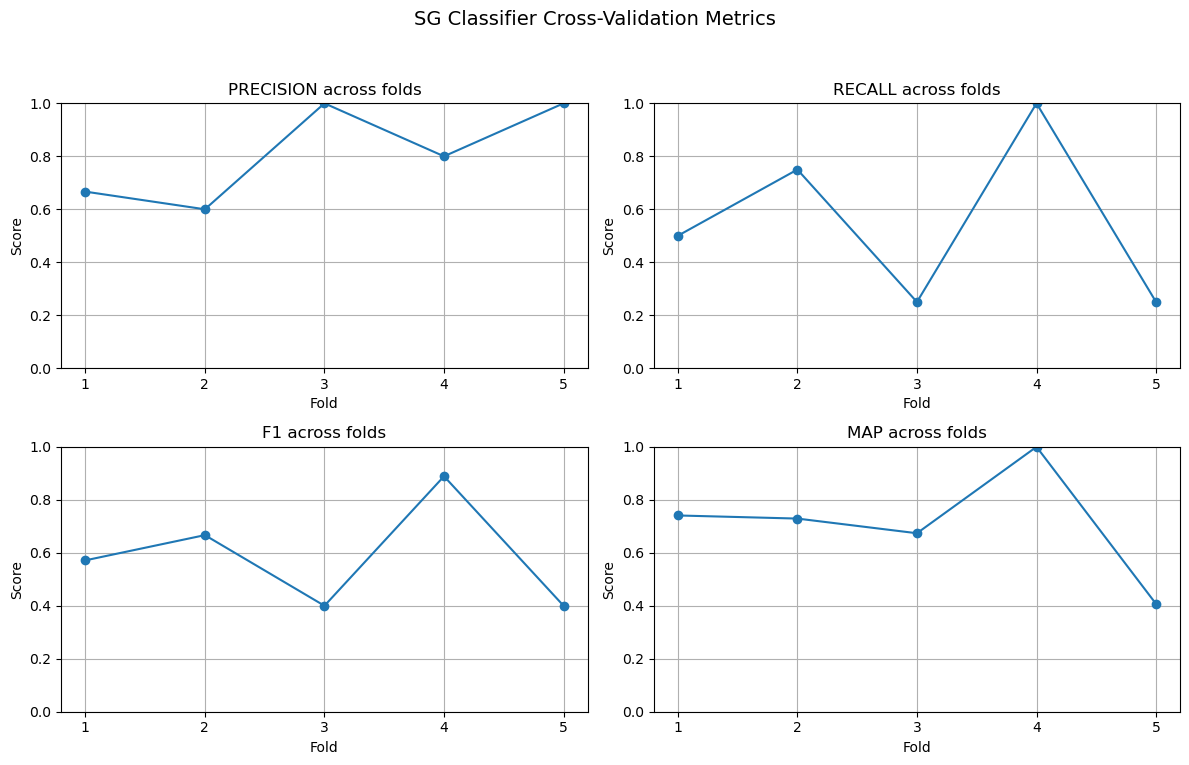

In [35]:
plot_cv_metrics(metrics_df, prefix="sg", save_path="cvb_metrics_sg_query8.5.v1.png")

#### Confusion Matrix of Testing

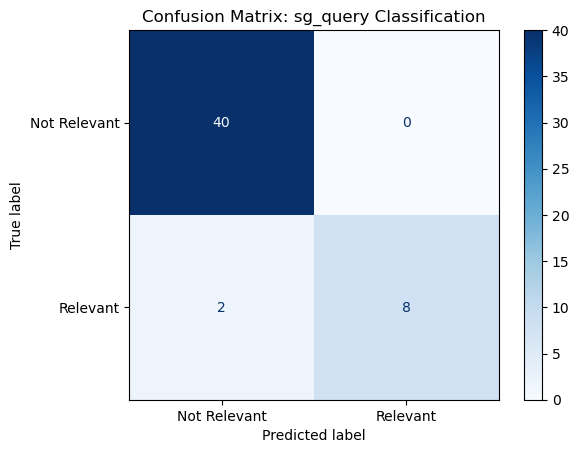

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Create the confusion matrix display object
disp = ConfusionMatrixDisplay.from_predictions(
    test_df["sg_query"], # was  heldout_df for NB
    test_df["sg_predicted"],
    display_labels=["Not Relevant", "Relevant"],
    cmap="Blues"
)

# Optional: set plot title
plt.title("Confusion Matrix: sg_query Classification")

# ---- git-safe save ----
DATA_VIS.mkdir(exist_ok=True)
save_path = DATA_VIS / "confusion_matrix_sg_query.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Plot saved to {save_path}")

# Show the plot (optional)
plt.show()

### Comparing Cosine IRS and cosineLR Classifier

#### Getting MAP Score

In [39]:
from sklearn.metrics import average_precision_score

# Drop missing values from relevant columns
eval_df = test_df.dropna(subset=["score_q1", "sg_prob", "sg_query"])

# Cosine similarity MAP@10
ap_cosine = average_precision_score(eval_df["sg_query"], eval_df["score_q1"])
print(f"Cosine MAP@10:      {ap_cosine:.4f}")

# Classifier MAP@10
ap_classifier = average_precision_score(eval_df["sg_query"], eval_df["sg_prob"])
print(f"Classifier MAP@10:  {ap_classifier:.4f}")


Cosine MAP@10:      0.8128
Classifier MAP@10:  0.9245


In [ ]:
# Show top classifier-based predictions using the same snippet viewer
#show_top_snippets((unlabeled_df.sort_values("sg_prob", ascending=False).head(10)), score_col="sg_prob", top_n=20)

#### Getting Ven Diagram of Cosine IRS and CosingLR Classifer Highest Ranked Articles

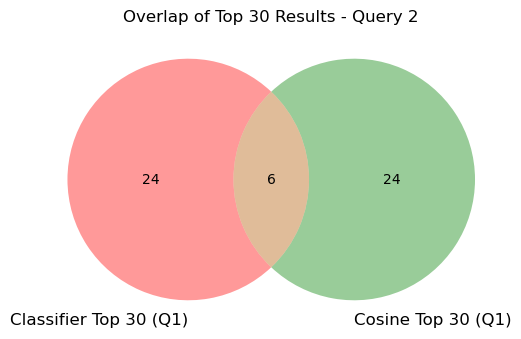

In [41]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Top 30 PMCIDs from classifier and cosine similarity (Query 2)
top_classifier = test_df.sort_values("sg_prob", ascending=False).head(30)["pmcid"]
top_cosine     = df.sort_values("score_q1", ascending=False).head(30)["pmcid"]

# Convert to sets
set_classifier = set(top_classifier)
set_cosine     = set(top_cosine)

# Plot Venn diagram
plt.figure(figsize=(6, 5))
venn2(
    [set_classifier, set_cosine],
    set_labels=("Classifier Top 30 (Q1)", "Cosine Top 30 (Q1)")
)
plt.title("Overlap of Top 30 Results - Query 2")
plt.show()

### Summary Data Extraction and Consoliation

#### Pedictions on unused data/test data

In [43]:
from sklearn.preprocessing import normalize

# Step 1: Define label and threshold
label_col = "sg_query"
threshold = 0.4

# Step 2: Get training and test PMCIDs separately
train_pmcs = set(train_df["pmcid"])
test_pmcs = set(test_df["pmcid"])

# Step 3: Get UNLABELED rows (not train or test)
unlabeled_df = df[~df["pmcid"].isin(train_pmcs.union(test_pmcs))].copy()
unlabeled_df = unlabeled_df.dropna(subset=["proc_text"])

# Step 4: Predict on unlabeled
X_unlabeled = normalize(vec_sg.transform(unlabeled_df["proc_text"]), norm='l2')
unlabeled_df["sg_prob"] = clf_sg.predict_proba(X_unlabeled)[:, 1]
unlabeled_df["sg_predicted"] = (unlabeled_df["sg_prob"] > threshold).astype(int)
unlabeled_df["source"] = "predicted"

# Step 5: Predict on test set only (not train)
X_test = normalize(vec_sg.transform(test_df["proc_text"]), norm='l2')
test_df["sg_prob"] = clf_sg.predict_proba(X_test)[:, 1]
test_df["sg_predicted"] = (test_df["sg_prob"] > threshold).astype(int)
test_df["source"] = "test"

# Step 6: Combine test + predicted only (no training data)
extract_df = pd.concat([test_df, unlabeled_df], axis=0)

# Step 7: Preview counts
print(extract_df["source"].value_counts())
print(f"Docs with sg_prob ≥ {threshold}: {extract_df[extract_df['sg_prob'] >= threshold].shape[0]}")




source
predicted    395
test          50
Name: count, dtype: int64
Docs with sg_prob ≥ 0.4: 20


#### Confusion Matrix for data (All Corpus is Labeled)

Confusion Matrix:
[[496   9]
 [  8  32]]

Classification Report:
              precision    recall  f1-score   support

Not Relevant       0.98      0.98      0.98       505
    Relevant       0.78      0.80      0.79        40

    accuracy                           0.97       545
   macro avg       0.88      0.89      0.89       545
weighted avg       0.97      0.97      0.97       545



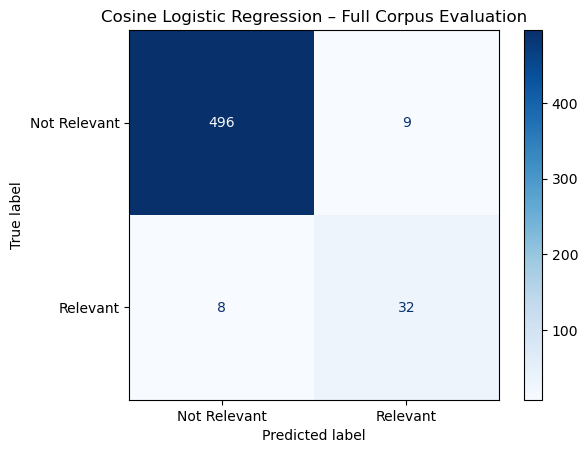

In [45]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize

# Make sure train_df has predictions too
if "sg_predicted" not in train_df.columns:
    X_train = normalize(vec_sg.transform(train_df["proc_text"]), norm='l2')
    train_df["sg_prob"] = clf_sg.predict_proba(X_train)[:, 1]
    train_df["sg_predicted"] = (train_df["sg_prob"] > threshold).astype(int)
    train_df["source"] = "train"

# Combine all 3 parts
full_df = pd.concat([train_df, test_df, unlabeled_df], axis=0)

# Filter to only rows with labels (which should now be all rows)
eval_df = full_df[full_df["sg_query"].isin([0, 1])]

# Generate confusion matrix
conf_mat = confusion_matrix(eval_df["sg_query"], eval_df["sg_predicted"])

# Print results
print("Confusion Matrix:")
print(conf_mat)

print("\nClassification Report:")
print(classification_report(eval_df["sg_query"], eval_df["sg_predicted"], target_names=["Not Relevant", "Relevant"]))

# Plot it
disp = ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=["Not Relevant", "Relevant"])
disp.plot(cmap="Blues")
plt.title("Cosine Logistic Regression – Full Corpus Evaluation")
plt.show()



#### Pattern Matching & Extraction Utilities

In [57]:
import re
import pandas as pd

def extract_group_sizes(text):
    """
    Sums all sample sizes (e.g. 'n = 12', 'n ≥ 7') found in the text.
    Assumes these are per-group and returns the total across groups.
    """
    matches = re.findall(r"n\s*[=≥]\s*(\d{1,3})", text, re.IGNORECASE)
    group_ns = [int(n) for n in matches if int(n) < 1000]
    return sum(group_ns) if group_ns else -9999

def extract_first_float(pattern, text):
    m = re.search(pattern, text, re.IGNORECASE)
    try:
        val = float(m.group(1)) if m else -9999
        if val < 0 or val > 1000:  # sanity check
            return -9999
        return val
    except:
        return -9999

def extract_list(pattern, text, stopwords=None):
    matches = re.findall(pattern, text, re.IGNORECASE)
    if not matches:
        return "-9999"
    stopwords = stopwords or {"in", "with", "and", "or", "of", "the", "we", "they", "like", "enriched", "depleted", "pathway", "pathways"}
    cleaned = [m.strip() for m in matches if m.lower() not in stopwords and len(m.strip()) > 2]
    return ", ".join(cleaned) if cleaned else "-9999"


def get_study_type(text):
    if re.search(r"mouse|rat|murine|sprague[- ]?dawley|pirc|aom", text, re.IGNORECASE):
        return "animal_model"
    elif re.search(r"clinical trial|randomized controlled|rct|healthy adults|patients|participants", text, re.IGNORECASE):
        return "clinical_trial"
    elif re.search(r"retrospective|chart review|case series", text, re.IGNORECASE):
        return "retrospective"
    else:
        return "other"

def extract_animal_age(text):
    match = re.search(r"(\d{1,2})[- ]?week[- ]?old", text, re.IGNORECASE)
    return int(match.group(1)) if match else -9999

def extract_animal_sex(text):
    if "male" in text.lower():
        return 100
    elif "female" in text.lower():
        return 0
    else:
        return -9999


# def compute_cosine_score(text, query_terms, vectorizer):
#     """
#     Computes cosine similarity using the pre-trained TF-IDF vectorizer.
#     Args:
#         text (str): Target text (e.g. combined article text).
#         query_terms (str): Terms or question to match.
#         vectorizer (TfidfVectorizer): Already fitted vectorizer from build_tfidf.

#     Returns:
#         float: Cosine similarity score rounded to 4 decimals.
#     """
#     X = vectorizer.transform([text, query_terms])
#     X = normalize(X, norm='l2')  # Ensure cosine is meaningful
#     return round(cosine_similarity(X[0:1], X[1:2]).flatten()[0], 4)



In [59]:
def extract_descriptive_stats(text):
    return {
        "n_subjects_total": extract_group_sizes(text),
        "pct_male": extract_animal_sex(text),
        "pct_female": 100 - extract_animal_sex(text) if extract_animal_sex(text) != -9999 else -9999,
        "mean_age": extract_animal_age(text),
        "mean_bmi": extract_first_float(r"\bbmi[^\d]{0,10}(\d{1,3}\.?\d*)", text),
        "study_type": get_study_type(text)
    }



In [61]:
def extract_microbiome_metrics(text):
    return {
        "shannon_index": extract_first_float(r"shannon[^a-zA-Z0-9]{0,10}(\d+\.\d+)", text),
        "simpson_index": extract_first_float(r"simpson[^a-zA-Z0-9]{0,10}(\d+\.\d+)", text),
        "chao1_index": extract_first_float(r"chao1[^a-zA-Z0-9]{0,10}(\d+\.\d+)", text),

        "alpha_pval": extract_first_float(r"alpha.*?p[ -]?value[^\d]*(0\.\d+)", text),
        "beta_pval": extract_first_float(r"permanova.*?p[ -]?value[^\d]*(0\.\d+)", text),
        "beta_r2": extract_first_float(r"permanova.*?r[\^2²]?[^\d]*(0\.\d+)", text),

        "diff_taxa_names": extract_list(r"\bfusobacterium nucleatum\b|\bbacteroides fragilis\b|\b[a-z]+bacterium\b", text),
        "fold_changes": extract_list(r"fold[- ]change[^\d]{0,10}(\d+\.\d+)", text),
        "taxa_pvals": extract_list(r"taxa.*?p[ -]?value[^\d]*(0\.\d+)", text),
        "fdr_pvals": extract_list(r"fdr[^\d]*(0\.\d+)", text),

        "fuso_detected": 1 if re.search(r"\bfusobacterium nucleatum\b", text, re.IGNORECASE) else 0,
        "b_frag_detected": 1 if re.search(r"\bbacteroides fragilis\b", text, re.IGNORECASE) else 0,

        "enriched_pathways": extract_list(r"enriched.*?pathways?[^a-zA-Z0-9]+([a-zA-Z0-9\-_]{4,})", text),
        "depleted_pathways": extract_list(r"depleted.*?pathways?[^a-zA-Z0-9]+([a-zA-Z0-9\-_]{4,})", text),

        "butyrate_conc": extract_first_float(r"butyrate[^\d]{0,10}(\d+\.\d+)", text),

        "auroc": extract_first_float(r"\bauroc[^\d]{0,10}(\d+\.\d+)", text),
        "sensitivity": extract_first_float(r"sensitivity[^\d]{0,10}(\d+\.\d+)", text),
        "specificity": extract_first_float(r"specificity[^\d]{0,10}(\d+\.\d+)", text),

        "hazard_ratio": extract_first_float(r"hazard ratio[^\d]{0,10}(\d+\.\d+)", text),
        "odds_ratio": extract_first_float(r"odds ratio[^\d]{0,10}(\d+\.\d+)", text),
        "ci_95": extract_list(r"(?:95% CI|95% confidence interval)[^\d]*(\d+\.\d+\s*[-–]\s*\d+\.\d+)", text)
    }



#### Data Extraction Pipeline

In [64]:
def stats_extract(df, output_csv="table1_sg_query.csv", prob_col="sg_prob", threshold=0.4, has_microbiome=True):
    rows = []

    # Only analyze relevant documents
    relevant_df = df[df[prob_col] >= threshold].copy()

    for _, row in relevant_df.iterrows():
        pmcid = row["pmcid"]
        combined_text = row.get("raw_text_stats", "")

        try:
            desc = extract_descriptive_stats(combined_text)
            micro = extract_microbiome_metrics(combined_text) if has_microbiome else {}

            all_stats = {
                **desc,
                **micro,
                prob_col: row.get(prob_col, -9999),
                "pmcid": pmcid,
                "url": f"https://www.ncbi.nlm.nih.gov/pmc/articles/{pmcid}/"
            }

            # Fallback if case study and no sample size
            if re.search(r"case report|case study", combined_text, re.IGNORECASE) and all_stats["n_subjects_total"] == -9999:
                all_stats["n_subjects_total"] = 1

            # Optional: flag bad rows for debugging
            missing_count = list(all_stats.values()).count(-9999)
            if missing_count > (0.5 * len(all_stats)):
                print(f"[WARN] PMC{pmcid} has {missing_count} missing fields")

            rows.append(all_stats)

        except Exception as e:
            print(f"[ERROR] Failed on PMC{pmcid}: {e}")
            continue

    out_df = pd.DataFrame(rows)
    out_df.to_csv(output_csv, index=False)
    print(f"Saved: {output_csv} ({len(out_df)} records)")






In [66]:
stats_extract(extract_df, output_csv="table1_sg_query.csv", prob_col="sg_prob", threshold=0.4, has_microbiome=True)

[WARN] PMCPMC12090783 has 17 missing fields
[WARN] PMCPMC11431989 has 16 missing fields
[WARN] PMCPMC11794788 has 17 missing fields
[WARN] PMCPMC11671356 has 17 missing fields
[WARN] PMCPMC11479648 has 17 missing fields
[WARN] PMCPMC11665664 has 17 missing fields
[WARN] PMCPMC11787111 has 16 missing fields
Saved: table1_sg_query.csv (20 records)


#### Interpretation – Query 1

## Query 2

### Query Run for Cosine IRS Comparison

In [68]:
top_q2 = run_query(
    query_text="Comparative benefit analysis of voluntary robotic surgery in treatment",
    vectorizer=vectorizer,
    tfidf_matrix=tfidf_matrix,
    df=df,
    score_colname="score_q2",
    normalize_by_length=True
)

# top_q2

# # ---- Show top results with snippets ----
# show_top_snippets(df, score_col="score_q1", top_n=20)

### Run Model With Query Labeled Column

In [70]:
test_df_th, vec_th, clf_th, metrics_df_th, test_metrics_th, conf_mat_th, train_df_th = run_cosine_logreg_pipeline(
    df,
    label_col="th_query",
    prefix="th",
    n_train_pos=12,
    n_train_neg=80,
    n_test_pos=7,
    n_test_neg=30,
    threshold=0.4
)




--- Cross-Validation Metrics ---
   fold  precision    recall        f1       map
0     1   1.000000  0.666667  0.800000  1.000000
1     2   0.666667  0.666667  0.666667  0.805556
2     3   1.000000  1.000000  1.000000  1.000000
3     4   1.000000  1.000000  1.000000  1.000000
4     5   0.666667  1.000000  0.800000  1.000000

--- Mean ± Std ---
PRECISION: 0.8667 ± 0.1826
RECALL: 0.8667 ± 0.1826
F1: 0.8533 ± 0.1445
MAP: 0.9611 ± 0.0870

--- Held-Out Test Metrics (th) ---
PRECISION: 0.7500
RECALL:    0.8571
F1 SCORE:  0.8000
MAP@10:    0.9325


### Plot Evaluation Metrics

#### Precsion/Recal/F1 Score For Training

Plot saved to cv_metricsclr_th_query8.5.png


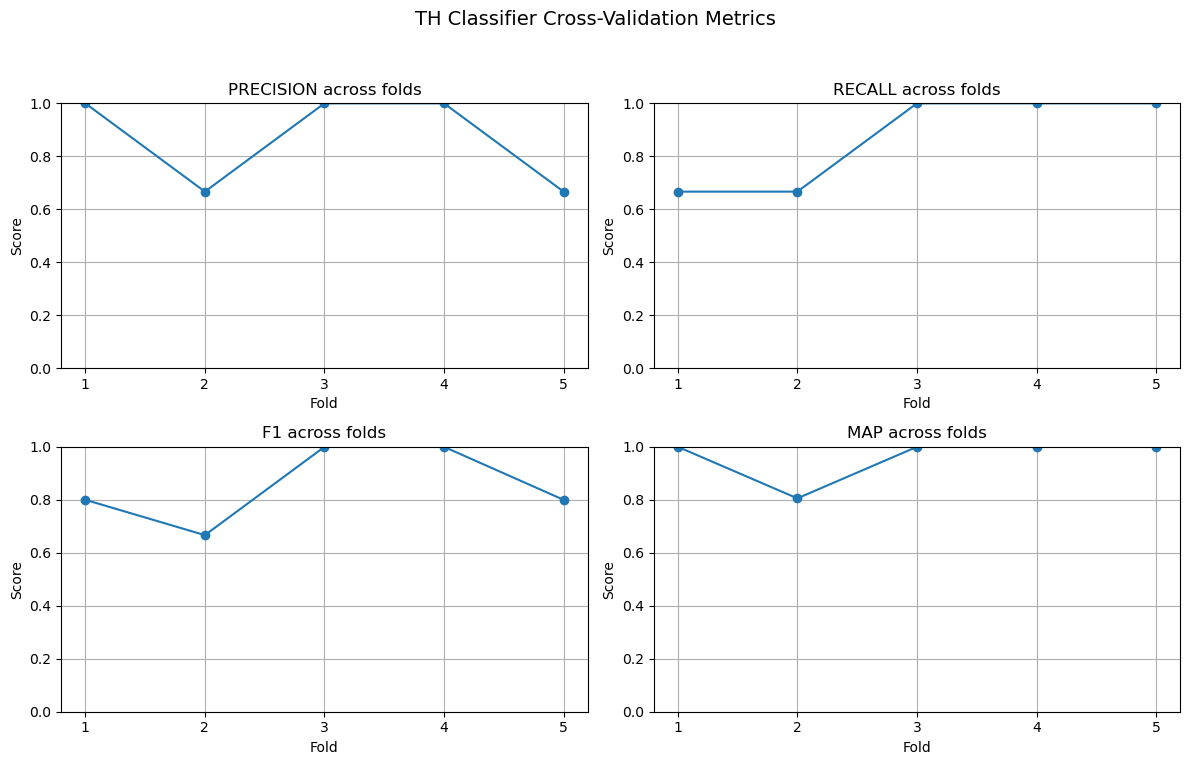

In [72]:
plot_cv_metrics(metrics_df_th, prefix="th", save_path="cv_metricsclr_th_query8.5.png")

#### Confusion Matrix of Testing

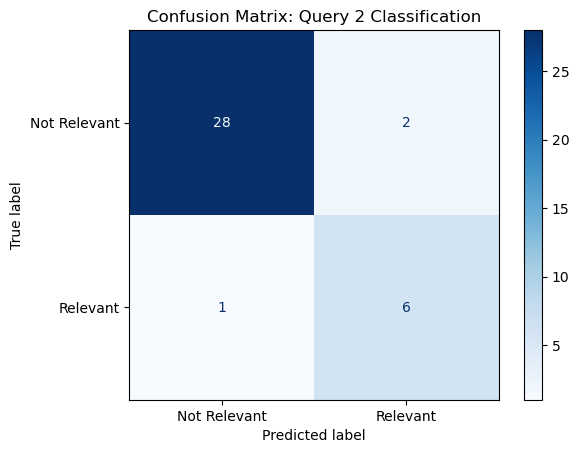

In [74]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Plot confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(
    test_df_th["th_query"],
    test_df_th["th_predicted"],
    display_labels=["Not Relevant", "Relevant"],
    cmap="Blues"
)

plt.title("Confusion Matrix: Query 2 Classification")

# ---- git-safe save ----
DATA_VIS.mkdir(exist_ok=True)
save_path = DATA_VIS / "confusion_matrix_th_query.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Plot saved to {save_path}")
plt.show()


### Comparing Cosine IRS and cosineLR Classifier

#### Getting MAP Scores

In [76]:
from sklearn.metrics import average_precision_score

# Drop missing values from relevant columns for Query 2
eval_df_th = test_df_th.dropna(subset=["score_q2", "th_prob", "th_query"])

# Cosine similarity MAP@10
ap_cosine_q2 = average_precision_score(eval_df_th["th_query"], eval_df_th["score_q2"])
print(f"Cosine MAP@10 (Q2):      {ap_cosine_q2:.4f}")

# Classifier MAP@10
ap_classifier_q2 = average_precision_score(eval_df_th["th_query"], eval_df_th["th_prob"])
print(f"Classifier MAP@10 (Q2):  {ap_classifier_q2:.4f}")


Cosine MAP@10 (Q2):      0.9683
Classifier MAP@10 (Q2):  0.9325


#### Getting Ven Diagram of Cosine IRS and CosineLR Classifier Top Choices

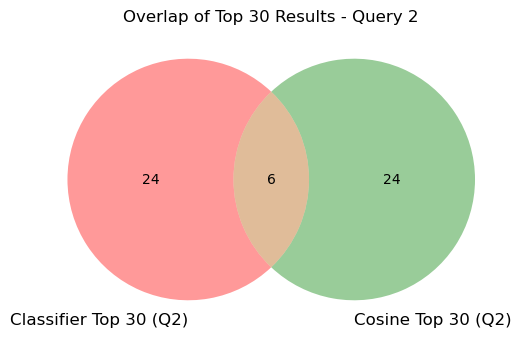

In [78]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

# Top 30 PMCIDs from classifier and cosine similarity (Query 2)
top_classifier_q2 = test_df_th.sort_values("th_prob", ascending=False).head(30)["pmcid"]
top_cosine_q2     = df.sort_values("score_q2", ascending=False).head(30)["pmcid"]

# Convert to sets
set_classifier_q2 = set(top_classifier_q2)
set_cosine_q2     = set(top_cosine_q2)

# Plot Venn diagram
plt.figure(figsize=(6, 5))
venn2(
    [set_classifier_q2, set_cosine_q2],
    set_labels=("Classifier Top 30 (Q2)", "Cosine Top 30 (Q2)")
)
plt.title("Overlap of Top 30 Results - Query 2")
plt.show()



### Summary Data Extractions

#### Predictions on unused data/test data

In [80]:
from sklearn.preprocessing import normalize

# Step 1: Define label and threshold
label_col = "th_query"
threshold = 0.4

# Step 2: Get training and test PMCIDs separately
train_pmcs_th = set(train_df_th["pmcid"])
test_pmcs_th = set(test_df_th["pmcid"])

# Step 3: Get UNLABELED rows (not train or test)
unlabeled_df_th = df[~df["pmcid"].isin(train_pmcs_th.union(test_pmcs_th))].copy()
unlabeled_df_th = unlabeled_df_th.dropna(subset=["proc_text"])

# Step 4: Predict on unlabeled
X_unlabeled_th = normalize(vec_th.transform(unlabeled_df_th["proc_text"]), norm='l2')
unlabeled_df_th["th_prob"] = clf_th.predict_proba(X_unlabeled_th)[:, 1]
unlabeled_df_th["th_predicted"] = (unlabeled_df_th["th_prob"] > threshold).astype(int)
unlabeled_df_th["source"] = "predicted"

# Step 5: Predict on test set only (not train)
X_test_th = normalize(vec_th.transform(test_df_th["proc_text"]), norm='l2')
test_df_th["th_prob"] = clf_th.predict_proba(X_test_th)[:, 1]
test_df_th["th_predicted"] = (test_df_th["th_prob"] > threshold).astype(int)
test_df_th["source"] = "test"

# Step 6: Combine test + predicted only (no training data)
extract_df_th = pd.concat([test_df_th, unlabeled_df_th], axis=0)

# Step 7: Preview counts
print(extract_df_th["source"].value_counts())
print(f"Docs with th_prob ≥ {threshold}: {extract_df_th[extract_df_th['th_prob'] >= threshold].shape[0]}")



source
predicted    416
test          37
Name: count, dtype: int64
Docs with th_prob ≥ 0.4: 20


#### Confusion Matrix for data

Confusion Matrix (Q2):
[[404  12]
 [  0   0]]

Classification Report (Q2):
              precision    recall  f1-score   support

Not Relevant       1.00      0.97      0.99       416
    Relevant       0.00      0.00      0.00         0

    accuracy                           0.97       416
   macro avg       0.50      0.49      0.49       416
weighted avg       1.00      0.97      0.99       416



C:\Users\miked\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\miked\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\miked\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


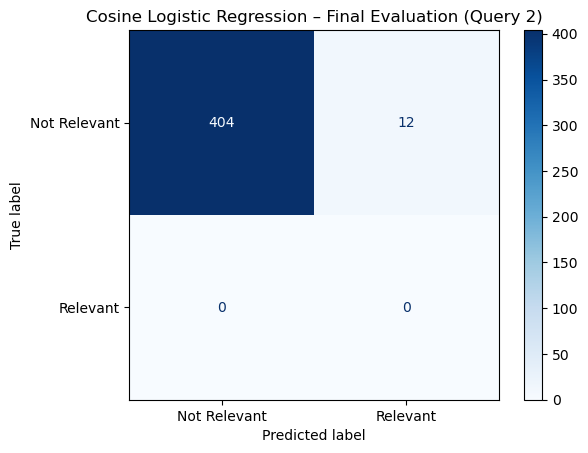

In [82]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Filter to rows that have ground truth th_query labels (0 or 1)
eval_df_th = unlabeled_df_th[unlabeled_df_th["th_query"].isin([0, 1])]

# Generate confusion matrix
conf_mat_th = confusion_matrix(eval_df_th["th_query"], eval_df_th["th_predicted"])

# Print confusion matrix and classification report
print("Confusion Matrix (Q2):")
print(conf_mat_th)

print("\nClassification Report (Q2):")
print(classification_report(eval_df_th["th_query"], eval_df_th["th_predicted"], target_names=["Not Relevant", "Relevant"]))

# Optional: Display it as a chart
disp_th = ConfusionMatrixDisplay(confusion_matrix=conf_mat_th, display_labels=["Not Relevant", "Relevant"])
disp_th.plot(cmap="Blues")
plt.title("Cosine Logistic Regression – Final Evaluation (Query 2)")
plt.show()



#### Data Extraction Pipeline

In [84]:
stats_extract(extract_df_th, output_csv="table1_th_query.csv", prob_col="th_prob", threshold=0.4, has_microbiome=False)

[WARN] PMCPMC11764117 has 5 missing fields
[WARN] PMCPMC11640554 has 5 missing fields
[WARN] PMCPMC12041975 has 5 missing fields
[WARN] PMCPMC12179861 has 5 missing fields
Saved: table1_th_query.csv (20 records)


### Interpretation - Query 2

In [ ]:
#show_top_snippets(test_df, score_col="sg_prob", label_col="sg_query", top_n=20)


In [ ]:
#show_top_snippets(test_df_th, score_col="th_prob", label_col="th_query", top_n=20)

## Saved Models

In [ ]:
# import joblib

# # Save classifier and vectorizer for Query 1
# joblib.dump(clf_sg, "clf_sg.pkl")
# joblib.dump(vec_sg, "vec_sg.pkl")

# # Save classifier and vectorizer for Query 2
# joblib.dump(clf_th, "clf_th.pkl")
# joblib.dump(vec_th, "vec_th.pkl")


# Data Exploration
- double checking xml files https://www.ncbi.nlm.nih.gov/pmc/articles/PMC11490504/ 

In [ ]:
df.shape
df[["word_count", "sentence_count"]].describe().transpose()
df["legit_coloncancer_article"].value_counts()
df.columns
df["note"].value_counts()

In [ ]:
plt.hist(df["word_count"], bins=30)
plt.title("Distribution of Word Counts")
plt.xlabel("Word Count")
plt.ylabel("Number of Documents")
plt.show()

In [ ]:
plt.hist(df["sentence_count"], bins=30, color="orange")
plt.title("Distribution of Sentence Counts")
plt.xlabel("Sentence Count")
plt.ylabel("Number of Documents")
plt.grid(True)
plt.show()

In [ ]:
df["journal"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 Journals in Corpus")
plt.xlabel("Number of Articles")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
df["pub_year"] = df["pub_year"].astype(str)
df["pub_year"].value_counts().sort_index().plot(kind="bar")
plt.title("Publications by Year")
plt.xlabel("Year")
plt.ylabel("Article Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(df['token_count'], bins=30)
plt.title("Distribution of Document Lengths (in tokens)")
plt.xlabel("Token count")
plt.ylabel("Number of articles")
plt.tight_layout()
plt.show()

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter to only the legit colon-cancer articles
subset = df[df['legit_coloncancer_article'] == 1]

# Flatten all tokens (no exclusions)
all_tokens = [tok for tokens in subset['tokens'] for tok in tokens]

# Combine into one string for word cloud
text_for_cloud = " ".join(all_tokens)

# Generate and plot
wc = WordCloud(
    width=800, 
    height=400, 
    background_color='white'
).generate(text_for_cloud)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — Legit Colon-Cancer Articles (All Terms)")
plt.show()

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Filter to only the legit colon-cancer articles
subset = df[df['legit_coloncancer_article'] == 1]

# Words to exclude
excluded_words = {"colorectal", "cancer", "colon", "figur", "fig"}

# Flatten tokens, filtering out excluded words
filtered_tokens = [tok for tokens in subset['tokens'] for tok in tokens if tok not in excluded_words]

# Combine into one string for word cloud
text_for_cloud = " ".join(filtered_tokens)

# Generate and plot
wc = WordCloud(
    width=800, 
    height=400, 
    background_color='white'
).generate(text_for_cloud)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — Legit Colon-Cancer Articles (Excluding Common Terms)")
plt.show()


In [ ]:
from collections import Counter

# Updated exclusion list
excluded_words = {"colorectal", "cancer", "colon", "patient","patients"}

# Filter relevant rows
subset = df[df['legit_coloncancer_article'] == 1]

# Flatten tokens while excluding specified words
filtered_tokens = [tok for tokens in subset['tokens'] for tok in tokens if tok not in excluded_words]

# Count token frequencies
token_counts = Counter(filtered_tokens)

# Get the 10 most common tokens
top_10 = token_counts.most_common(10)

# Display
for word, count in top_10:
    print(f"{word}: {count}")


# Extract words and frequencies
words = list(token_counts.keys())
counts = list(token_counts.values())

# Plot
plt.figure(figsize=(10, 6))
plt.bar(words, counts)
plt.xlabel("Token")
plt.ylabel("Frequency")
plt.title("Top 10 Most Frequent Tokens")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Feasibility Summary